<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-quiz-marks-ml-100?scriptVersionId=251199485" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-quiz-marks-dataset/marks_final.csv


## Title : 
Student Quiz Marks

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/student-quiz-marks-dataset/marks_final.csv')

In [3]:
df.head()

,SNO.,ROLL NUMBER,Q1 (5),Q2 (5),Q3 (5),Q4 (5),Q5 (5),Q6 (5),Q7 (5),Q8 (5),Q9 (5),Q10 (5),Q11 (5),Q12 (5),Top 9 (out of 45),Out of 30
0,1,102003733,AB,AB,AB,AB,AB,AB,3,5,AB,AB,AB,4,12,8.0
1,2,102203002,5,AB,4,4,4,4,4,3,5,5,5,3,40,26.7
2,3,102203003,5,4,4,4,4,5,4,3,4,5,4,2,39,26.0
3,4,102203005,AB,AB,AB,AB,3,5,3,4,4,5,5,AB,29,19.3
4,5,102203007,AB,AB,AB,5,4,3,3,5,3,5,5,3,36,24.0


In [4]:
df.tail()

,SNO.,ROLL NUMBER,Q1 (5),Q2 (5),Q3 (5),Q4 (5),Q5 (5),Q6 (5),Q7 (5),Q8 (5),Q9 (5),Q10 (5),Q11 (5),Q12 (5),Top 9 (out of 45),Out of 30
1048,1049,102383062,5,4,AB,5,3,4,AB,3,4,5,4,5,39,26.0
1049,1050,102383067,5,2,3,4,3,5,2,5,AB,5,5,5,40,26.7
1050,1051,102383071,5,3,5,4,3,3,4,5,4,5,5,5,42,28.0
1051,1052,102383081,5,3,3,AB,4,AB,AB,5,AB,5,5,3,33,22.0
1052,1053,102383083,AB,AB,3,AB,5,AB,4,AB,AB,4,5,3,24,16.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SNO.               1053 non-null   int64  
 1   ROLL NUMBER        1053 non-null   int64  
 2   Q1 (5)             1053 non-null   object 
 3   Q2 (5)             1053 non-null   object 
 4   Q3 (5)             1053 non-null   object 
 5   Q4 (5)             1053 non-null   object 
 6   Q5 (5)             1053 non-null   object 
 7   Q6 (5)             1053 non-null   object 
 8   Q7 (5)             1053 non-null   object 
 9   Q8 (5)             1053 non-null   object 
 10  Q9 (5)             1053 non-null   object 
 11  Q10 (5)            1053 non-null   object 
 12  Q11 (5)            1053 non-null   object 
 13  Q12 (5)            1053 non-null   object 
 14  Top 9 (out of 45)  1053 non-null   int64  
 15  Out of 30          1053 non-null   float64
dtypes: float64(1), int64(3),

In [6]:
df.describe()

,SNO.,ROLL NUMBER,Top 9 (out of 45),Out of 30
count,1053.00000,1.053000e+03,1053.000000,1053.000000
mean,527.00000,1.027862e+08,38.144349,25.430104
std,304.11922,1.848957e+07,7.150877,4.766492
min,1.00000,1.020037e+08,0.000000,0.000000
25%,264.00000,1.022033e+08,37.000000,24.700000
50%,527.00000,1.022035e+08,40.000000,26.700000
75%,790.00000,1.022038e+08,42.000000,28.000000
max,1053.00000,7.022000e+08,45.000000,30.000000


In [7]:
df.isnull().sum()

SNO.                 0
ROLL NUMBER          0
Q1 (5)               0
Q2 (5)               0
Q3 (5)               0
Q4 (5)               0
Q5 (5)               0
Q6 (5)               0
Q7 (5)               0
Q8 (5)               0
Q9 (5)               0
Q10 (5)              0
Q11 (5)              0
Q12 (5)              0
Top 9 (out of 45)    0
Out of 30            0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(1053, 16)

In [10]:
df.dtypes

SNO.                   int64
ROLL NUMBER            int64
Q1 (5)                object
Q2 (5)                object
Q3 (5)                object
Q4 (5)                object
Q5 (5)                object
Q6 (5)                object
Q7 (5)                object
Q8 (5)                object
Q9 (5)                object
Q10 (5)               object
Q11 (5)               object
Q12 (5)               object
Top 9 (out of 45)      int64
Out of 30            float64
dtype: object

In [11]:
df.columns

Index(['SNO.', 'ROLL NUMBER', 'Q1 (5)', 'Q2 (5)', 'Q3 (5)', 'Q4 (5)', 'Q5 (5)',
       'Q6 (5)', 'Q7 (5)', 'Q8 (5)', 'Q9 (5)', 'Q10 (5)', 'Q11 (5)', 'Q12 (5)',
       'Top 9 (out of 45)', 'Out of 30'],
      dtype='object')

## Data visualizations

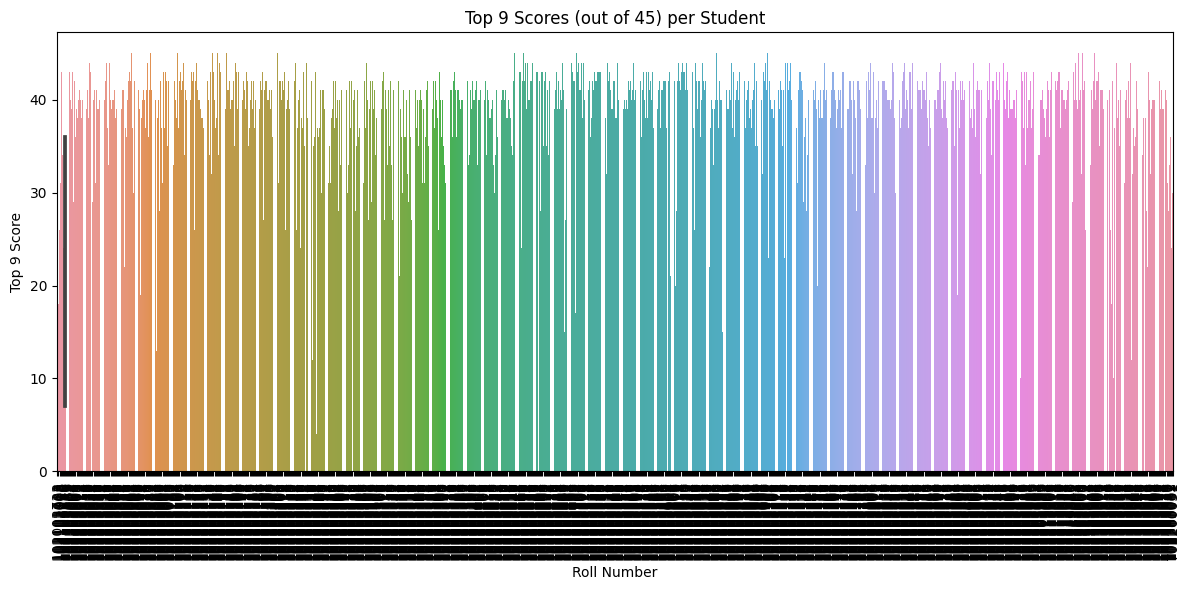

In [12]:
# Convert columns to proper format
question_cols = [col for col in df.columns if '(5)' in col]
df[question_cols] = df[question_cols].apply(pd.to_numeric, errors='coerce')
df['Top 9 (out of 45)'] = pd.to_numeric(df['Top 9 (out of 45)'], errors='coerce')
df['Out of 30'] = pd.to_numeric(df['Out of 30'], errors='coerce')

# --- 1. Bar Plot: Total Top 9 Scores per Student ---
plt.figure(figsize=(12, 6))
sns.barplot(x='ROLL NUMBER', y='Top 9 (out of 45)', data=df)
plt.xticks(rotation=90)
plt.title('Top 9 Scores (out of 45) per Student')
plt.ylabel('Top 9 Score')
plt.xlabel('Roll Number')
plt.tight_layout()
plt.show()

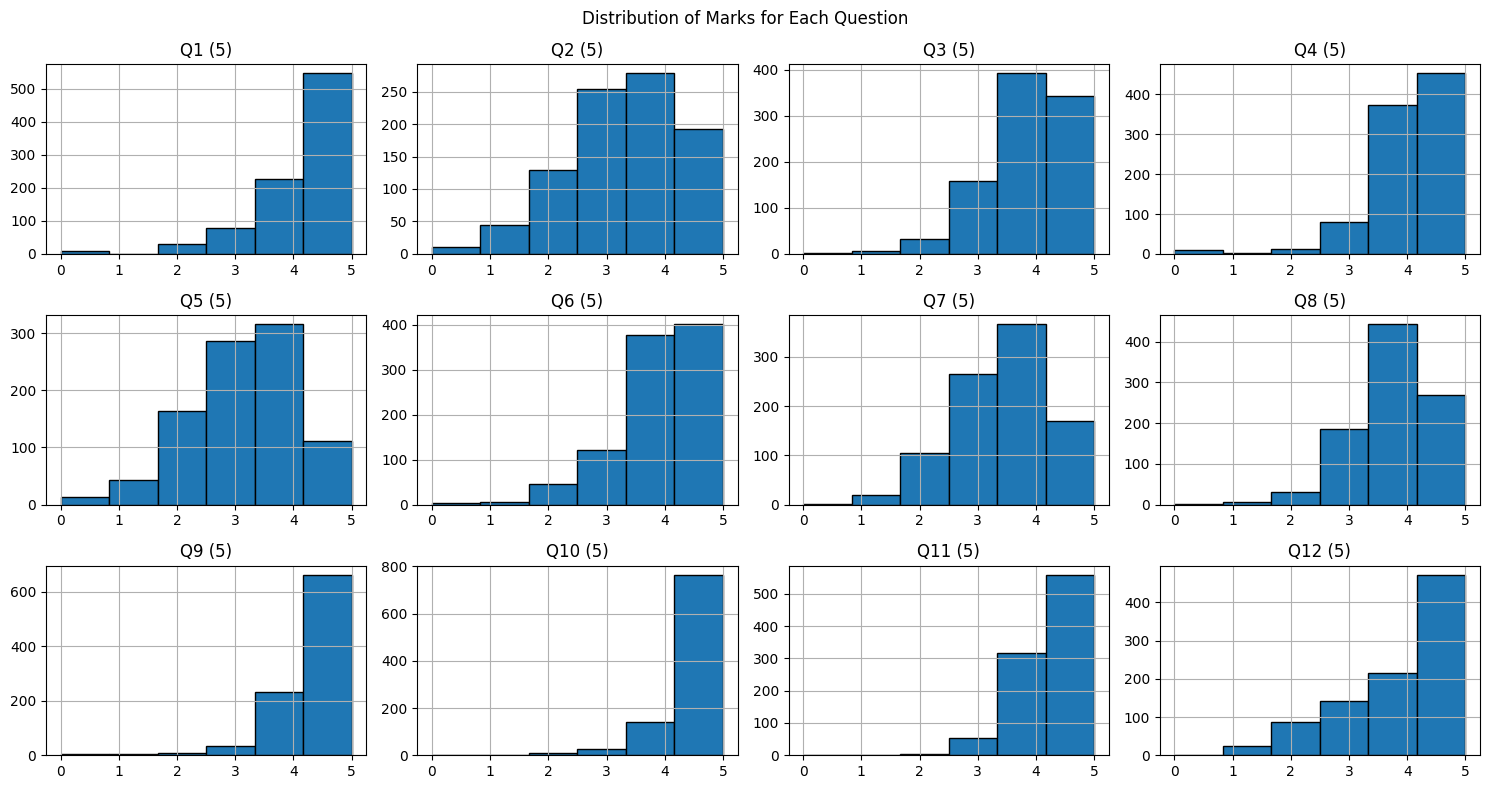

In [13]:
# --- 2. Histogram for Each Question ---
df[question_cols].hist(bins=6, figsize=(15, 8), layout=(3, 4), edgecolor='black')
plt.suptitle('Distribution of Marks for Each Question')
plt.tight_layout()
plt.show()

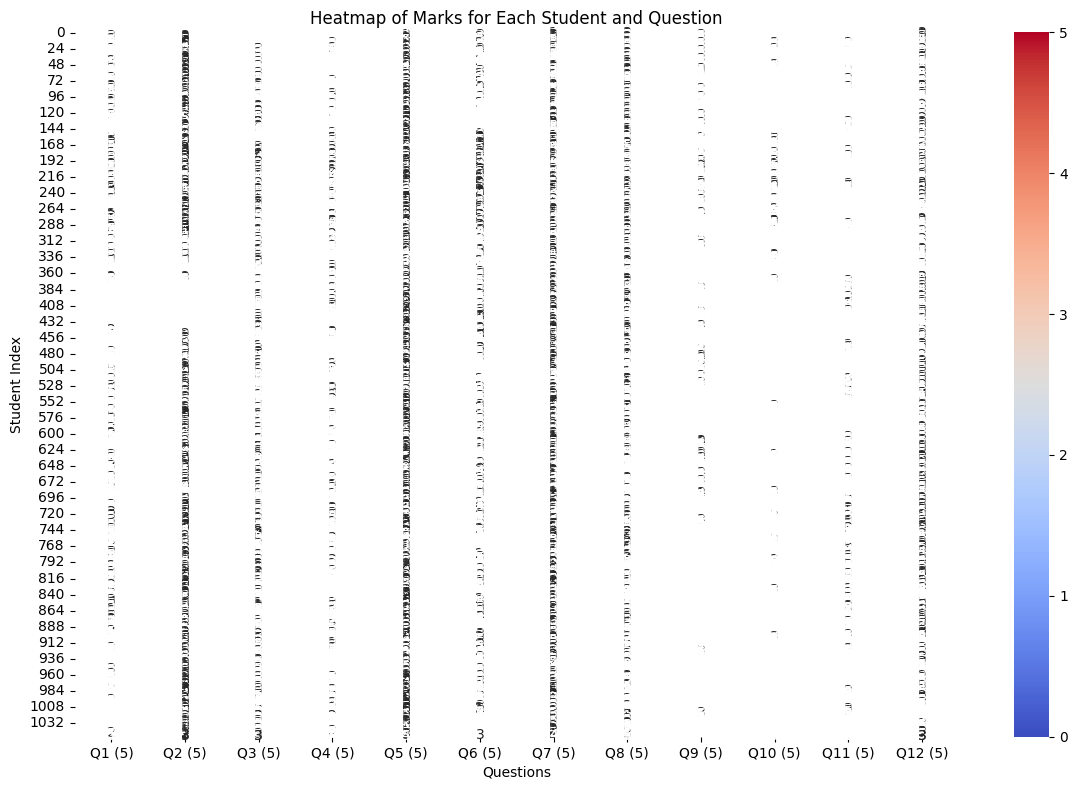

In [14]:
# --- 3. Heatmap: Student vs Questions ---
plt.figure(figsize=(12, 8))
sns.heatmap(df[question_cols], annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap of Marks for Each Student and Question')
plt.xlabel('Questions')
plt.ylabel('Student Index')
plt.tight_layout()
plt.show()

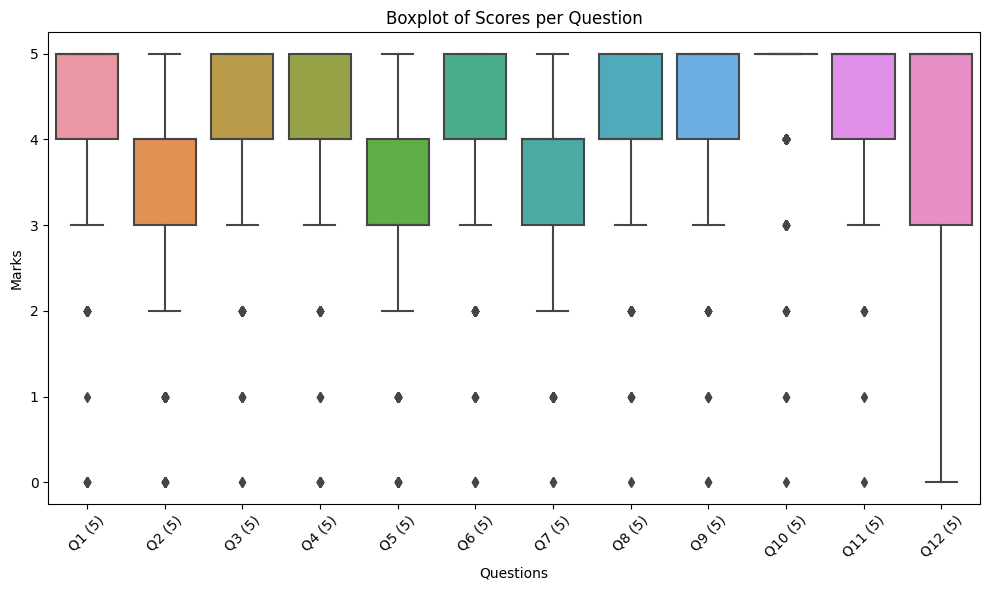

In [15]:
# --- 4. Boxplot: Performance Spread per Question ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[question_cols])
plt.title('Boxplot of Scores per Question')
plt.ylabel('Marks')
plt.xlabel('Questions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


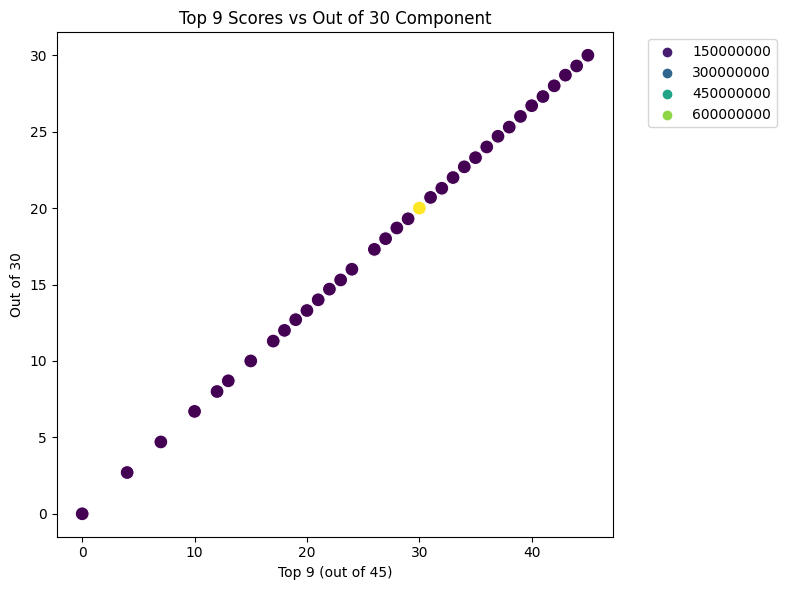

In [16]:
# --- 5. Scatter Plot: Top 9 vs Out of 30 ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Top 9 (out of 45)', y='Out of 30', data=df, hue='ROLL NUMBER', palette='viridis', s=100)
plt.title('Top 9 Scores vs Out of 30 Component')
plt.xlabel('Top 9 (out of 45)')
plt.ylabel('Out of 30')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# Step 1: Preprocess
question_cols = [col for col in df.columns if '(5)' in col]
df['Top 9 (out of 45)'] = pd.to_numeric(df['Top 9 (out of 45)'], errors='coerce')
df['Out of 30'] = pd.to_numeric(df['Out of 30'], errors='coerce')
df[question_cols] = df[question_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)

# Create Total Score
df['Total_Score'] = df['Top 9 (out of 45)'] + df['Out of 30']

# Create Target: Performance Level
def get_performance(score):
    if score >= 65:
        return 'High'
    elif score >= 50:
        return 'Medium'
    else:
        return 'Low'

df['Performance'] = df['Total_Score'].apply(get_performance)

# Encode Target
le = LabelEncoder()
df['Performance_encoded'] = le.fit_transform(df['Performance'])  # Low:0, Medium:1, High:2

# Step 2: Split features and target
X = df[question_cols + ['Top 9 (out of 45)', 'Out of 30']]
y = df['Performance_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Logistic Regression: 100.00%
Decision Tree: 100.00%
Random Forest: 100.00%
K-Nearest Neighbors: 96.67%
Support Vector Machine: 91.11%
Naive Bayes: 100.00%


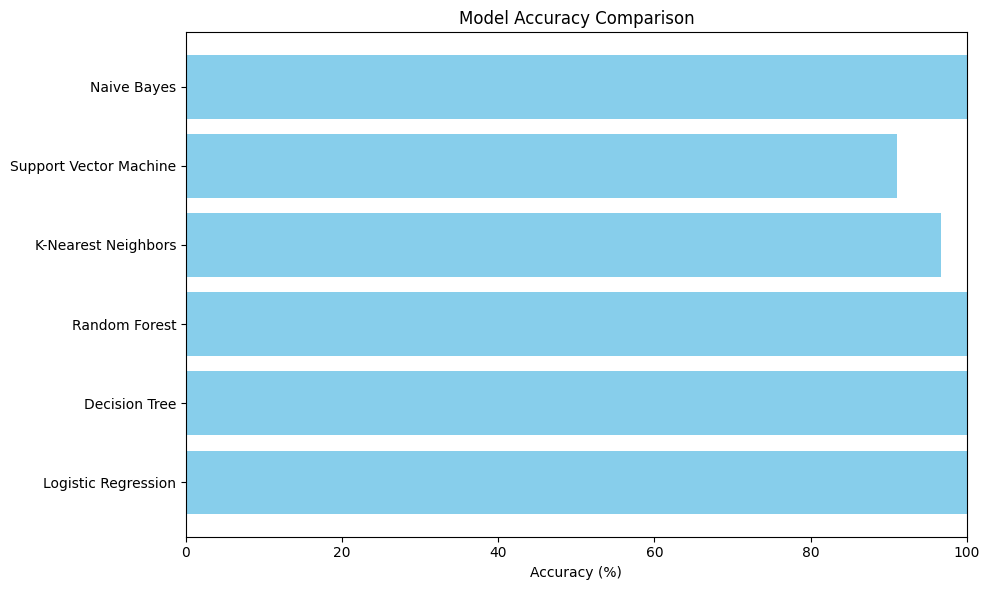

In [19]:
# Step 3: Apply Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB()
}

# Step 4: Train & Evaluate
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_scores[name] = acc
    print(f"{name}: {acc:.2f}%")

# Optional: Show as bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(list(accuracy_scores.keys()), list(accuracy_scores.values()), color='skyblue')
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Thank you ...pls upvote!!!!
